In [1]:
import xarray as xr
import numpy as np
from tvolib import matplotlib_utils as mu

import mmspy
from mmspy.computation.particle import (
    ParticleGrid,
    interpolate_distribution,
)

mms = mmspy.api.MMS()
mms.query.probe = "mms1"
mms.query.data_rate = "brst"
mms.query.start_date = "2017-07-26T07:25:00"
mms.query.end_date = "2017-07-26T07:27:00"

2025-02-04 20:29:08,927 [INFO]: Using tvolib stylesheet
2025-02-04 20:29:08,977 [INFO]: Using Python-MIP package version 1.16rc0
2025-02-04 20:29:09,817 [WARNING]: /home/tvo/.local/share/mamba/envs/mmspy/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



In [3]:
fgm = mms.load_dataset(instrument="fgm", data_type="bfield")
ion_ref = mms.load_dataset(instrument="fpi", data_type="ion_moments")
elc_ref = mms.load_dataset(instrument="fpi", data_type="elc_moments")
ion = (
    mms.load_dataset(instrument="fpi", data_type="ion_distribution")
    .fpi.add_field_aligned_coordinates(fgm.B_gse, average=True)
)
elc = (
    mms.load_dataset(instrument="fpi", data_type="elc_distribution")
    .fpi.add_field_aligned_coordinates(fgm.B_gse, average=True)
)

[################] [2/2 | 121.72it/s]: Synchronizing fgm bfield (2017-07-26 07:25:00 - 2017-07-26 07:27:00).
[################] [2/2 | 107.42it/s]: Synchronizing fpi ion_moments (2017-07-26 07:25:00 - 2017-07-26 07:27:00).
[################] [2/2 | 103.84it/s]: Synchronizing fpi elc_moments (2017-07-26 07:25:00 - 2017-07-26 07:27:00).
[################] [2/2 | 150.36it/s]: Synchronizing fpi ion_distribution (2017-07-26 07:25:00 - 2017-07-26 07:27:00).
[################] [2/2 | 124.61it/s]: Synchronizing fpi elc_distribution (2017-07-26 07:25:00 - 2017-07-26 07:27:00).


In [4]:
f_unit = "s3 m-6"

ion_ref["V"] = (ion_ref.W.dims, ion_ref.W.data.to("velocity_unit", "ion"))
elc_ref["V"] = (elc_ref.W.dims, elc_ref.W.data.to("velocity_unit", "elc"))
ion_ref["f_omni"] = (2 / ion_ref.V**4 * ion_ref.j_omni).pint.to(f_unit)
elc_ref["f_omni"] = (2 / elc_ref.V**4 * elc_ref.j_omni).pint.to(f_unit)

In [7]:
def precondition_fpi(ds):
    ds = ds[["f", "f_err", "W", "theta_dbcs", "phi_dbcs", "theta_fac", "phi_fac"]].copy()
    
    not_time_dimensions = [dim for dim in ds.dims if dim != "time"]
    ds["f_norm"] = xr.where(ds.f > 0, ds.f, np.nan).min(not_time_dimensions).pint.to(f_unit)
    ds["f_u"] = (ds.f / ds.f_norm).pint.to("dimensionless")
    ds["f_u_err"] = (ds.f_err / ds.f_norm).pint.to("dimensionless")
    
    integrate_dimensions = ("zenith_sector", "azimuthal_sector")
    dJ = np.sin(ds.theta_dbcs) * xr.ones_like(ds.phi_dbcs)
    J = dJ.sum(integrate_dimensions)
    ds["f_omni_u"] = (ds.f_u * dJ).sum(integrate_dimensions) / J
    ds["f_omni_u_err"] = np.sqrt(((ds.f_u_err * dJ)**2).sum(integrate_dimensions)) / J
    ds["f_omni"] = ds.f_omni_u * ds.f_norm
    ds["f_omni_err"] = ds.f_omni_u_err * ds.f_norm
    
    return ds

ion = precondition_fpi(ion)
elc = precondition_fpi(elc)

In [24]:
from pint import application_registry as u

grid = {
    "W": ParticleGrid(
        name="energy",
        center=np.logspace(np.log10(1e0), np.log10(4e4), 39) * u.eV,
        log_scale=True,
    ),
    "theta_fac": ParticleGrid(
        name="zenith",
        center=np.linspace(0, 180, 19) * u.deg,
        log_scale=False,
    ),
    "phi_fac": ParticleGrid(
        name="azimuth",
        center=np.linspace(0, 360, 37) * u.deg,
        log_scale=False,
    ),
}
grid_1d = {key: value for key, value in grid.items() if key == "W"}
f_ion = interpolate_distribution(ion, grid_1d, variable="f_omni_u", mode="mean") * ion.f_norm
f_ion_std = interpolate_distribution(ion, grid_1d, variable="f_omni_u", mode="spread") * ion.f_norm
f_ion_err = interpolate_distribution(ion, grid_1d, variable="f_omni_u_err", mode="error") * ion.f_norm

f_elc = interpolate_distribution(elc, grid_1d, variable="f_omni_u", mode="mean") * elc.f_norm
f_elc_std = interpolate_distribution(elc, grid_1d, variable="f_omni_u", mode="spread") * elc.f_norm
f_elc_err = interpolate_distribution(elc, grid_1d, variable="f_omni_u_err", mode="error") * elc.f_norm

2025-02-04 20:54:23,162 [WARNING]: /home/tvo/.local/share/mamba/envs/mmspy/lib/python3.12/site-packages/xarray/core/variable.py:352: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)



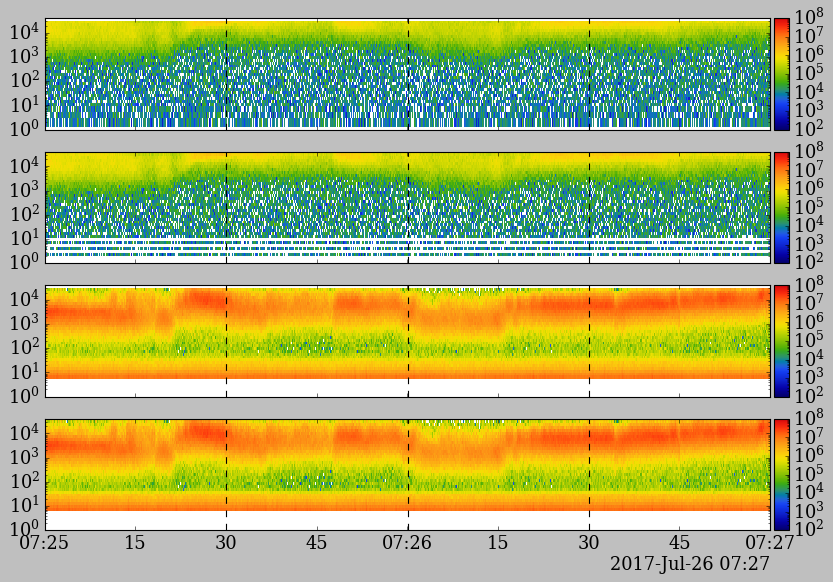

In [25]:
V_ion = f_ion.W.data.to("velocity_unit", "ion")
j_ion = (0.5 * V_ion**4 * f_ion).pint.to("number_flux_unit")

V_elc = f_elc.W.data.to("velocity_unit", "elc")
j_elc = (0.5 * V_elc**4 * f_elc).pint.to("number_flux_unit")

fig, axes = mu.plt.subplots(4, 1, figsize=(12, 8), sharex=True)
pkw = {"cmap": "cet_rainbow4", "norm": mu.mplc.LogNorm(1e2, 1e8)}

Nt = ion_ref.time.size

cax = mu.add_colorbar(ax := axes[0])
im = ax.pcolormesh(
    ion_ref.time + xr.zeros_like(ion_ref.W.pint.dequantify(), dtype="timedelta64"),
    ion_ref.W.pint.dequantify(),
    ion_ref.j_omni.pint.dequantify(),
    **pkw,
)
fig.colorbar(im, cax=cax)

cax = mu.add_colorbar(ax := axes[1])
im = ax.pcolormesh(
    *np.meshgrid(j_ion.time, j_ion.W.pint.dequantify(), indexing="ij"),
    j_ion.pint.dequantify(),
    **pkw,
)
fig.colorbar(im, cax=cax)

cax = mu.add_colorbar(ax := axes[2])
im = ax.pcolormesh(
    elc_ref.time + xr.zeros_like(elc_ref.W.pint.dequantify(), dtype="timedelta64"),
    elc_ref.W.pint.dequantify(),
    elc_ref.j_omni.pint.dequantify(),
    **pkw,
)
fig.colorbar(im, cax=cax)

cax = mu.add_colorbar(ax := axes[3])
im = ax.pcolormesh(
    *np.meshgrid(j_elc.time, j_elc.W.pint.dequantify(), indexing="ij"),
    j_elc.pint.dequantify(),
    **pkw,
)
fig.colorbar(im, cax=cax)

for i, ax in enumerate(axes):
    mu.format_datetime_labels(ax)
    ax.set_yscale("log")
    ax.set_ylim(j_ion.W[0].values, j_ion.W[-1].values)
    for i, it in enumerate([1 * Nt // 4, 2 * Nt // 4, 3 * Nt // 4]):
        ax.axvline(ion_ref.time[it].values, ls="--")

mu.plt.show()

2025-02-04 21:04:06,001 [WARNING]: /home/tvo/.local/share/mamba/envs/mmspy/lib/python3.12/site-packages/xarray/core/variable.py:352: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)



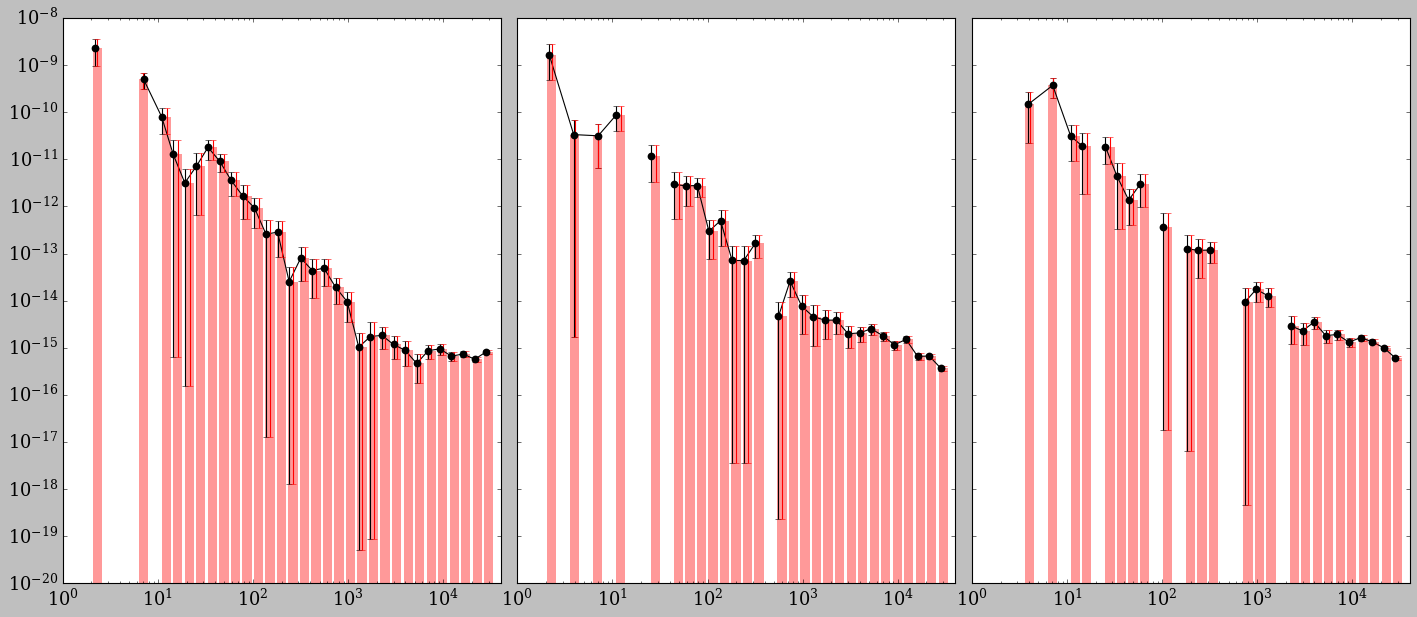

In [36]:
fig, axes = mu.plt.subplots(1, 3, figsize=(18, 8), sharex=True, sharey=True)
ekw = {"mec": "none", "ms": 7, "fmt": "o"}
hkw = {"edgecolor": "none", "alpha": 0.4}

W = f_ion.W.data

for i, it in enumerate([1 * Nt // 4, 2 * Nt // 4, 3 * Nt // 4]):
    axes[i].plot(
        ion_ref.W.isel(time=it).pint.dequantify(),
        xr.where(ion_ref.f_omni > 0, ion_ref.f_omni, np.nan).isel(time=it).pint.dequantify(),
        "-k",
    )
    axes[i].errorbar(
        ion.W.isel(time=it).pint.dequantify(),
        ion.f_omni.isel(time=it).pint.dequantify(),
        yerr=ion.f_omni_err.isel(time=it).pint.dequantify(),
        c="k",
        **ekw,
    )
    axes[i].bar(
        f_ion.W.pint.dequantify(),
        f_ion.isel(time=it).pint.dequantify(),
        yerr=f_ion_err.isel(time=it).pint.dequantify(),
        width=0.8 * np.diff(grid["W"].edge.magnitude),
        facecolor="r",
        ecolor="r",
        **hkw,
    )

for i, ax in enumerate(axes):
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(f_ion.W[0].values, f_ion.W[-1].values)

fig.tight_layout(h_pad=0.05, w_pad=0.05)
mu.plt.show()

2025-02-04 21:05:05,057 [WARNING]: /home/tvo/.local/share/mamba/envs/mmspy/lib/python3.12/site-packages/xarray/core/variable.py:352: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)



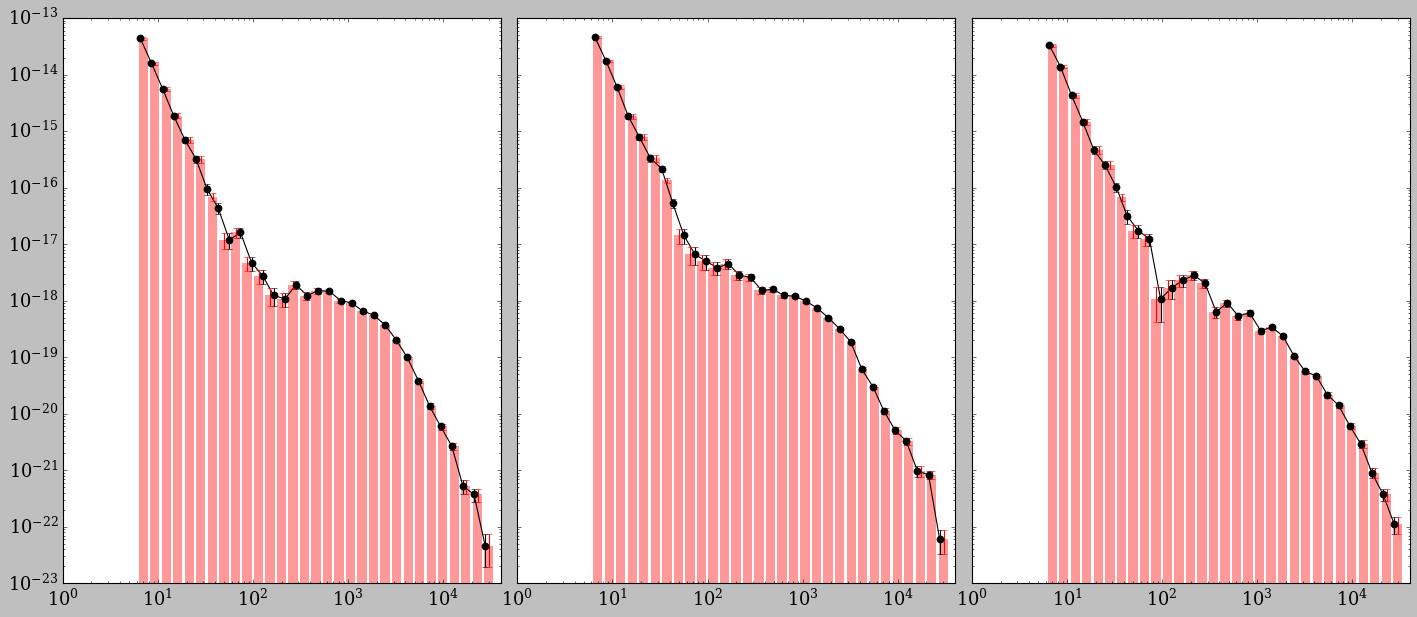

In [37]:
fig, axes = mu.plt.subplots(1, 3, figsize=(18, 8), sharex=True, sharey=True)
ekw = {"mec": "none", "ms": 7, "fmt": "o"}
hkw = {"edgecolor": "none", "alpha": 0.4}

W = f_elc.W.data

for i, it in enumerate([1 * Nt // 4, 2 * Nt // 4, 3 * Nt // 4]):
    axes[i].plot(
        elc_ref.W.isel(time=it).pint.dequantify(),
        xr.where(elc_ref.f_omni > 0, elc_ref.f_omni, np.nan).isel(time=it).pint.dequantify(),
        "-k",
    )
    axes[i].errorbar(
        elc.W.isel(time=it).pint.dequantify(),
        elc.f_omni.isel(time=it).pint.dequantify(),
        yerr=elc.f_omni_err.isel(time=it).pint.dequantify(),
        c="k",
        **ekw,
    )
    axes[i].bar(
        f_elc.W.pint.dequantify(),
        f_elc.isel(time=it).pint.dequantify(),
        yerr=f_elc_err.isel(time=it).pint.dequantify(),
        width=0.8 * np.diff(grid["W"].edge.magnitude),
        facecolor="r",
        ecolor="r",
        **hkw,
    )

for i, ax in enumerate(axes):
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(f_elc.W[0].values, f_elc.W[-1].values)

fig.tight_layout(h_pad=0.05, w_pad=0.05)
mu.plt.show()